In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [11]:
image_path = "../output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

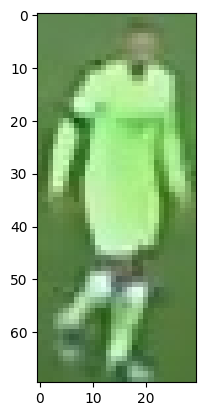

In [12]:
plt.imshow(image)
plt.show()

## Take the tophalf of the image

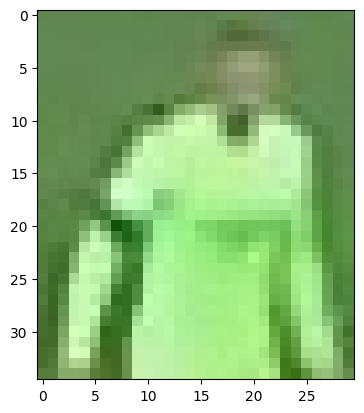

In [13]:
top_half_image = image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

## Cluster the image into two clusters

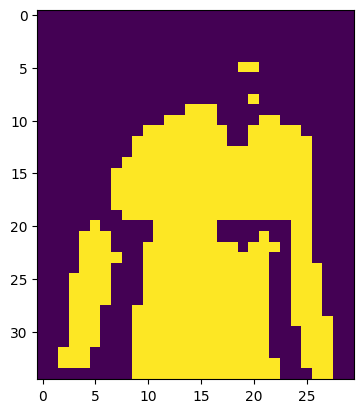

In [26]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# Perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# Get cluster labels
labels = kmeans.labels_

# Reshape de labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])
plt.imshow(clustered_image)
plt.show()

In [27]:
corner_clusters = [
    clustered_image[0, 0],
    clustered_image[0, -1],
    clustered_image[-1, 0],
    clustered_image[-1, -1]
]

non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [28]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [30]:
kmeans.cluster_centers_[player_cluster]

array([172.76443418, 234.25866051, 148.4965358 ])